In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import pickle
from pathlib import Path

# Configuration
DATA_DIR = Path('folktables_results')
OUTPUT_DIR = Path('plots')
N_SEEDS = 3
THRESHOLD = 0.10  # 10% difference threshold

In [8]:
STATES = ['CA', 'TX', 'FL', 'NY']
MODELS = ['LR', 'GBM', 'GBM_tun', 'GBM_opt']

In [9]:
model_dict = {'LR': 'LR', 'GBM': 'GBM (coarse)' , 'GBM_tun': 'GBM (tuned)', 'GBM_opt': 'GBM (fine)'}

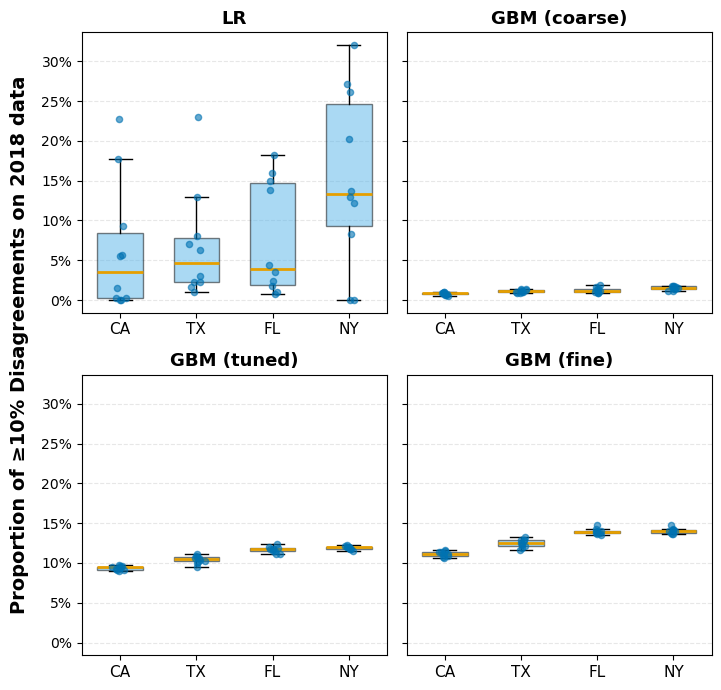

In [10]:
# Collect results
proportions_list = []

for state in STATES:
    for model_name in MODELS:
        
        # load data
        mult_filename = DATA_DIR / f"mult_{state}_income_{model_name}.pkl"
        with open(mult_filename, 'rb') as f:
            multiplicity_data = pickle.load(f)
        
        probs_2017 = np.array(multiplicity_data['2017'])
        probs_2014_2017 = np.array(multiplicity_data['2014-2017'])

        # Calculate proportion for each seed
        prob_diffs = np.abs(probs_2017 - probs_2014_2017)
        proportions = (prob_diffs >= THRESHOLD).mean(axis=1)
        
        proportions_list.append({
                'state': state,
                'model': model_name,
                'proportions': proportions
            })

df_proportions = pd.DataFrame(proportions_list)


# Create plot
fig, axes = plt.subplots(2, 2, figsize=(7, 7), sharey=True)
axes_flat = axes.flatten()

for idx, model in enumerate(MODELS):
    ax = axes_flat[idx]
    model_data = df_proportions[df_proportions['model'] == model].set_index('state')
    
    # Extract proportions for each state (simpler list comprehension)
    box_data = [model_data.loc[state, 'proportions'] for state in STATES if state in model_data.index]
    
    # Create box plot
    bp = ax.boxplot(box_data, widths=0.6, patch_artist=True, showfliers=False,
                    boxprops=dict(facecolor='#56B4E9', alpha=0.5),
                    medianprops=dict(color='#E69F00', linewidth=2))
    
    # Overlay individual points with jitter
    for i, props in enumerate(box_data):
        jitter = np.random.normal(0, 0.04, size=len(props))
        ax.scatter(i + 1 + jitter, props, color='#0072B2', alpha=0.6, s=20, zorder=3)
    
    # Formatting
    ax.set_title(model_dict[model], fontsize=13, fontweight='bold')
    ax.set_xticklabels(STATES, fontsize=11)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))

# Axis description
fig.text(-0.01, 0.5, 'Proportion of ≥10% Disagreements on 2018 data', 
         va='center', ha='center', rotation='vertical', 
         fontsize=14, fontweight='bold')

plt.subplots_adjust(left=0.08)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'exp_b_multiplicity_2x2.png', dpi=300, bbox_inches='tight')
plt.show()

### accuracy of trained models

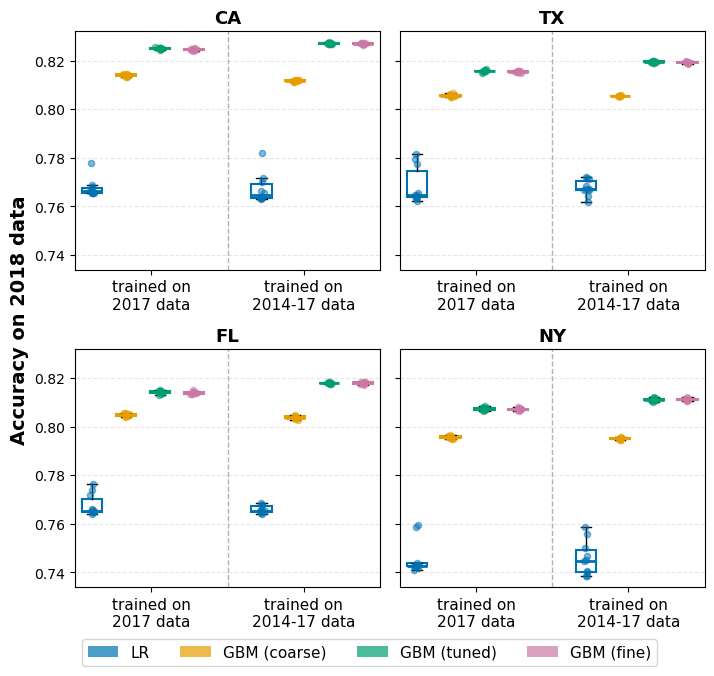

In [11]:
# Order training configs chronologically
train_settings = ['2017', '2014-2017']
x_labels = ['trained on\n2017 data', 'trained on\n2014-17 data']
# Okabe-Ito palette — colorblind safe
colors = ['#0072B2', '#E69F00', '#009E73', '#CC79A7']
fig, axes = plt.subplots(2, 2, figsize=(7, 6.5), sharey=True)
axes_flat = axes.flatten()
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[i], alpha=0.7, label=model_dict[model]) 
                   for i, model in enumerate(MODELS)]
for idx, state in enumerate(STATES):
    ax = axes_flat[idx]
    
    # prepare boxplots
    box_data = []
    box_positions = []
    box_colors = []
    
    for j, model in enumerate(MODELS):
        data = pd.read_csv(DATA_DIR / f"exp_b_{state}_income_{model}.csv")
        
        for i, config in enumerate(train_settings):
            subset = data[data['train_config'] == config]['accuracy']
            if len(subset) > 0:
                box_data.append(subset.values)
                box_positions.append(i * (len(MODELS) + 1) + j)
                box_colors.append(colors[j])
    
    # draw boxplots
    bp = ax.boxplot(box_data, positions=box_positions, widths=0.6,
                    patch_artist=True, showfliers=False)
    
    for patch, median, color in zip(bp['boxes'], bp['medians'], box_colors):
        patch.set_facecolor('none')
        patch.set_edgecolor(color)
        patch.set_linewidth(1.5)
        median.set_color(color)
        median.set_linewidth(2)
    
    for i, (props, color) in enumerate(zip(box_data, box_colors)):
        jitter = np.random.normal(0, 0.04, size=len(props))
        ax.scatter(box_positions[i] + jitter, props,
                   color=color, alpha=0.5, s=20, zorder=3)
        
    # formatting
    ax.set_title(f'{state}', fontsize=13, fontweight='bold')
    group_centers = [1.75, 6.25]
    ax.set_xticks(group_centers, )
    ax.set_xticklabels(x_labels, fontsize=11)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    # add vertical dashed line between the two groups
    ax.axvline(x=4, color='gray', linestyle='--', linewidth=1, alpha=0.6)

# axis description and legend
fig.text(-0.00, 0.5, 'Accuracy on 2018 data', va='center', ha='center', rotation='vertical',
        fontsize=14, fontweight='bold')
fig.legend(handles=legend_elements,
           loc='upper center', bbox_to_anchor=(0.5, 0.02),
           ncol=len(MODELS),  # horizontal layout
           frameon=True, fontsize=11)

plt.subplots_adjust(left=0.08, bottom=0.11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'exp_b_accuracy_2x2.png', dpi=300, bbox_inches='tight')
plt.show()